# AdaLQO: Adaptive Learned Query Optimizer with Shifting Detector

In [1]:
import argparse
import time
import os

import numpy as np
import pandas as pd
import torch
import sys
import AdaLQO.utils as utils
from AdaLQO.utils import plot_res
from AdaLQO.utils import prediction
from AdaLQO.shift_detector import mmd,ws,ks_values_pca

sys.path.insert(0, 'bao_server')
import bao_server.model as bao_model
import copy
import random

# sys.path.append('ShiftHandler')
# from replay_buffer import summarizer

In [2]:
df = utils.load_data("tpc-ds")
BATCH_SIZE = 20
# data = utils.split_dataset(df, batch_size=BATCH_SIZE, random_state=42)

In [3]:
df.shape

(2567, 7)

In [4]:
# Filter queries that use PostgreSQL's default execution timeout
df_psql_overtime = df[df.apply(lambda x: x['latency_list'][0] is None, axis=1)]
print(df_psql_overtime.shape)

(228, 7)


In [5]:
df = df[df.apply(lambda x: x['latency_list'][0] is not None, axis=1)]
print(df.shape)

(2339, 7)


In [6]:
# Remove inf latencies
df["latency_list"] = df["latency_list"].apply(
    lambda xs: [x for x in xs if x is not None] if isinstance(xs, list) else []
)

In [7]:
mismatched_rows = df[df.apply(lambda x: len(x['latency_list']) != len(x['plans']), axis=1)]
# varify all latency/plan paired
assert(mismatched_rows.shape[0] == 0)

In [8]:
# Remove
df = df[
    df["latency_list"].apply(lambda xs: isinstance(xs, list) and len(xs) > 0)
    & df["plans"].apply(lambda xs: isinstance(xs, list) and len(xs) > 0)
]
df = df.reset_index(drop=True)

print(df.shape)

(2339, 7)


In [9]:
overtime_rows = df[df.apply(lambda x: len(x['latency_list']) < 13, axis=1)]
# varify all latency/plan paired
print(overtime_rows.shape)

(228, 7)


In [10]:
data = utils.split_dataset(df, batch_size=BATCH_SIZE, random_state=None)

## Init Model


In [11]:
def init_bao_model(data):
    X, y = utils.get_training_data(data[0][0])

    # TODO:// have_cache_data=False, since Buffer Feature missed. Fix it later
    reg = bao_model.BaoRegression(have_cache_data=False, verbose=False)
    try:
        reg.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)

    reg.fit_model(X, y, seed=42, ada_size=False)
    return reg

## 3. Queries(Plans) Featurization

In [12]:
def embedding_plans(regressor, batch):
    all_plans = []
    for plans in batch["plans"]:
        all_plans.extend(plans)
    trees = regressor._BaoRegression__tree_transform.transform(all_plans)
    return regressor._BaoRegression__net.get_fixed_features(trees)

## 4. Predict Other Group Data & Continual Learning

In [13]:
import bao_server.featurize as f

def safe_prediction(model, data):
    try:
        return prediction(model, data)
    except f.TreeBuilderError as e:
        print("TreeBuilderError during prediction:", e)
        print("Refitting feature extractor and model on current batch...")

        X = []
        y = []

        for _, row in data.iterrows():
            X.extend(row["plans"])
            y.extend(row["latency_list"])

        model.fit_feature_extractor(X, y)
        model.fit_model(X, y, seed=42, ada_size=False)

        return prediction(model, data)

In [28]:
def cl(regressor, shift_detect, data):
    res = []
    base_data = data[0][0]
    base_embedding = embedding_plans(regressor, base_data)
    pre_data = data[0][0]
    ori_reg = copy.deepcopy(regressor)

    for i, phase in enumerate(data):
        for j, batch in enumerate(phase):
            # Skip  the first batch
            if i+j == 0:
                continue
            cur_embedding = embedding_plans(regressor, batch)
            match shift_detect:
                case "mmd":
                    mmd_score = mmd(cur_embedding, base_embedding)
                    print(i, j, mmd_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if mmd_score > 0.1:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ks":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ks_score = ks_values_pca(cur, base)
                    print(i, j, ks_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ks_score.statistic > 0.2:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ws":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ws_score = ws(cur, base)
                    print(i, j, ws_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ws_score > 0.5:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
            try:
                ori_res = prediction(ori_reg, batch)
            except f.TreeBuilderError:
                ori_res = safe_prediction(ori_reg, batch)
            cur_res = safe_prediction(regressor, batch)
            cur_res["base_bao_latency"] = ori_res["bao_latency"]
            res.append(cur_res)
            pre_data = data[i][j]

    return res


def retrain_model(base_embedding, pre_data, regressor):
    base_data = pre_data
    X, y = utils.get_training_data(base_data)
    try:
        regressor.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)
    regressor.fit_model(X, y, seed=42, ada_size=False)
    base_embedding = embedding_plans(regressor, base_data)
    return base_embedding


## 5. Maximum Mean Discrepancy (MMD)

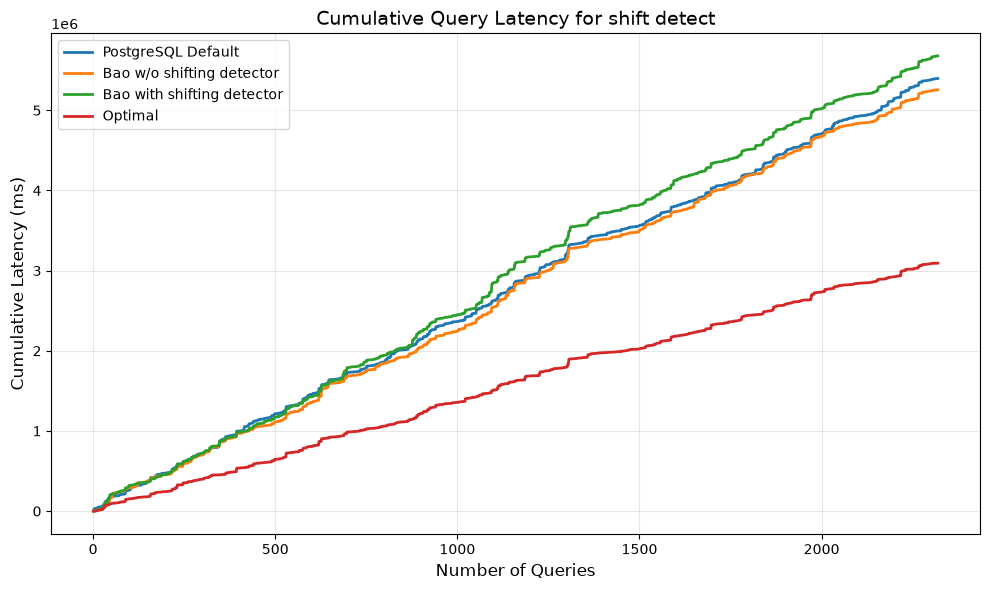

In [27]:
reg = init_bao_model(data)
res = cl(reg,"mmd",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/tpcds/performance_10_mmd.png")

### Relationship of MMD score & Regret

## 7. Kolmogorov-Smirnov (KS) test

In [24]:
# reg = init_bao_model(data)
# res = cl(reg,"ks",data)
# res_df = pd.concat(res,ignore_index=True)
# plot_res("shift detect", res_df, "results/tpcds/performance_10_ks.png")

### KL-Divergence Or JSD vs Regrets (Optional)

## 9. Wassertein Distance vs Regrets

In [23]:
# reg = init_bao_model(data)
# res = cl(reg,"ws",data)
# res_df = pd.concat(res,ignore_index=True)
# plot_res("shift detect", res_df, "results/tpcds/performance_20_ws.png")

Therefore, I recommend using the following main figures for the final paper:

Normalized Latency (Default/Bao/Optimal) ← Main Figure

Regret vs Phase ← Core Results

MMD Score + Retrain Point ← Method Validation

Top-1 Accuracy ← Auxiliary Results

These four figures should be sufficient to fully support the experimental section of the entire Continual LQO paper.
因此我建议最终论文主图用：
Normalized Latency (Default/Bao/Optimal) ← 主图
Regret vs Phase ← 核心结果
MMD Score + Retrain Point ← 方法验证
Top-1 Accuracy ← 辅助结果
这四张图基本就能完整支撑整个 Continual LQO 论文的实验部分。